# Data Exploration & Visualization

## Financial RAG System - Banking Document Analysis

This notebook performs comprehensive data exploration and visualization of the pre-processed banking document chunks.

**Objectives:**
- Load and analyze chunk metadata
- Generate dataset statistics
- Create visualizations for document distribution, bank analysis, and text characteristics
- Perform data quality checks
- Export processed data for further analysis


In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Add src to path for importing utilities
sys.path.append('../src')

from utils.chunk_loader import ChunkMetadataLoader

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


## 1. Data Loading

Load the chunk metadata from the JSON file using the ChunkMetadataLoader utility.


In [2]:
# Create necessary directories
Path('results/visualizations').mkdir(parents=True, exist_ok=True)
Path('data/processed').mkdir(parents=True, exist_ok=True)

print("✓ Directories created")

# Load data
print("\nLoading data...")
try:
    loader = ChunkMetadataLoader(
        metadata_path='../chunk_metadata/chunk_metadata.json',
        faiss_path='../chunk_metadata/rag_index.faiss'
    )
    loader.load()
    print("✓ Data loaded successfully")
except FileNotFoundError as e:
    print(f"❌ Error: File not found - {e}")
    raise
except Exception as e:
    print(f"❌ Error loading data: {e}")
    raise


INFO:utils.chunk_loader:Loading chunk metadata...


✓ Directories created

Loading data...


INFO:utils.chunk_loader:Loading FAISS index...
INFO:utils.chunk_loader:✅ Loaded 27283 chunks and FAISS index with 27283 vectors


✓ Data loaded successfully


## 2. Dataset Statistics

Extract and display key statistics about the dataset.


In [3]:
# Get metadata
metadata = loader.get_metadata()
chunks = loader.get_chunks()

# Print dataset overview
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total Chunks: {len(chunks)}")
print(f"Embedding Dimension: {metadata.get('embedding_dimension', 'N/A')}")
print(f"Chunk Size: {metadata.get('chunk_size', 'N/A')}")
print(f"Chunk Overlap: {metadata.get('chunk_overlap', 'N/A')}")
print(f"Embedding Model: {metadata.get('embedding_model', 'N/A')}")
print("=" * 50)


DATASET OVERVIEW
Total Chunks: 27283
Embedding Dimension: 384
Chunk Size: 512
Chunk Overlap: 100
Embedding Model: all-MiniLM-L6-v2


## 3. Create DataFrame

Convert chunks to a pandas DataFrame for easier analysis.


In [4]:
# Create DataFrame from chunks
data_rows = []
for chunk in chunks:
    meta = chunk.get('metadata', {})
    content = chunk.get('content', '')
    
    # Calculate text statistics
    text_length = len(content)
    word_count = len(content.split()) if content else 0
    
    row = {
        'chunk_id': chunk.get('chunk_id', ''),
        'bank_name': meta.get('doc_name', 'Unknown'),
        'document_type': meta.get('document_type', 'other'),
        'page_number': meta.get('page', None),
        'product_type': meta.get('product_type', 'other'),
        'text_length': text_length,
        'word_count': word_count
    }
    data_rows.append(row)

df = pd.DataFrame(data_rows)

print(f"DataFrame shape: {df.shape}")
print(f"\nDataFrame columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


DataFrame shape: (27283, 7)

DataFrame columns: ['chunk_id', 'bank_name', 'document_type', 'page_number', 'product_type', 'text_length', 'word_count']

First few rows:


,chunk_id,bank_name,document_type,page_number,product_type,text_length,word_count
0,6932b16d0a96ead392bd8549-0,HBL,other,None,other,320,55
1,6932b16d0a96ead392bd8549-1,HBL,other,None,other,470,68
2,6932b16d0a96ead392bd8549-2,HBL,other,None,other,504,80
3,6932b16d0a96ead392bd8549-3,HBL,other,None,other,416,69
4,6932b16d0a96ead392bd8549-4,HBL,other,None,other,441,77


## 4. Summary Statistics

Generate descriptive statistics for text length and word count.


In [5]:
# Summary statistics
print("=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)
stats = df[['text_length', 'word_count']].describe()
print(stats.to_string())
print("=" * 50)


SUMMARY STATISTICS
        text_length    word_count
count  27283.000000  27283.000000
mean     627.943261    101.274713
std      517.742488     81.785649
min      117.000000     15.000000
25%      353.000000     57.000000
50%      472.000000     77.000000
75%      723.000000    118.000000
max     5652.000000    882.000000


## 5. Data Quality Checks

Perform data quality validation checks.


In [6]:
# Data quality checks
print("=" * 50)
print("DATA QUALITY CHECKS")
print("=" * 50)

missing_bank_names = df['bank_name'].isna().sum() + (df['bank_name'] == 'Unknown').sum()
missing_doc_types = df['document_type'].isna().sum()
chunks_lt_10_words = (df['word_count'] < 10).sum()
chunks_gt_500_words = (df['word_count'] > 500).sum()

print(f"Missing bank names: {missing_bank_names}")
print(f"Missing document types: {missing_doc_types}")
print(f"Chunks with <10 words: {chunks_lt_10_words}")
print(f"Chunks with >500 words: {chunks_gt_500_words}")
print("=" * 50)


DATA QUALITY CHECKS
Missing bank names: 0
Missing document types: 0
Chunks with <10 words: 0
Chunks with >500 words: 93


## 6. Visualizations

Create comprehensive visualizations to understand the data distribution.


Creating visualizations...
✓ Saved: data_distribution.png


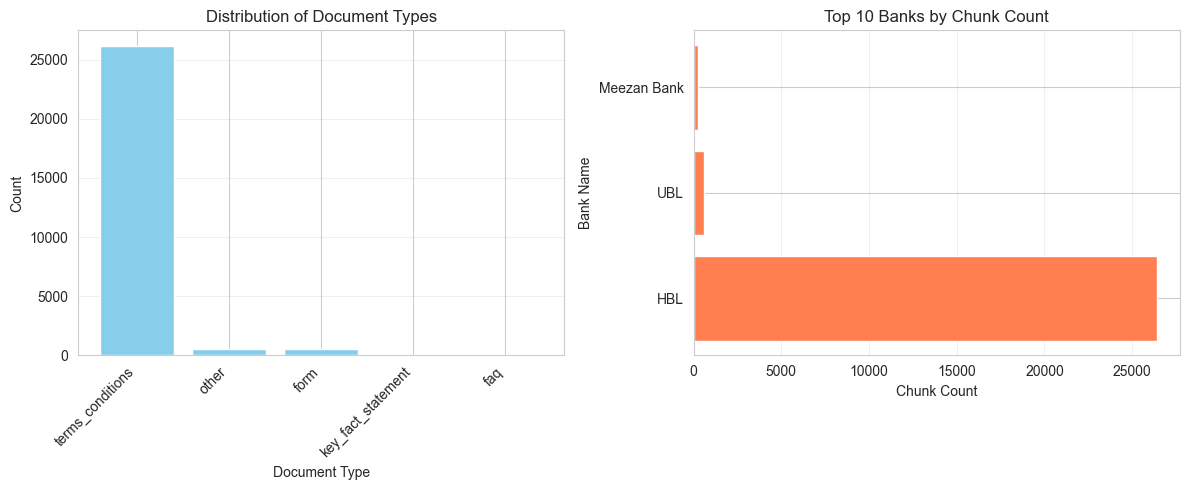

In [7]:
print("Creating visualizations...")

# Visualization 1 & 2: Document Type Distribution and Top 10 Banks (subplot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Document Type Distribution
doc_type_counts = df['document_type'].value_counts()
ax1.bar(range(len(doc_type_counts)), doc_type_counts.values, color='skyblue')
ax1.set_xticks(range(len(doc_type_counts)))
ax1.set_xticklabels(doc_type_counts.index, rotation=45, ha='right')
ax1.set_xlabel('Document Type')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Document Types')
ax1.grid(axis='y', alpha=0.3)

# Top 10 Banks
bank_counts = df['bank_name'].value_counts().head(10)
ax2.barh(range(len(bank_counts)), bank_counts.values, color='coral')
ax2.set_yticks(range(len(bank_counts)))
ax2.set_yticklabels(bank_counts.index)
ax2.set_xlabel('Chunk Count')
ax2.set_ylabel('Bank Name')
ax2.set_title('Top 10 Banks by Chunk Count')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('results/visualizations/data_distribution.png', bbox_inches='tight', dpi=300)
print("✓ Saved: data_distribution.png")
plt.show()


✓ Saved: word_count_distribution.png


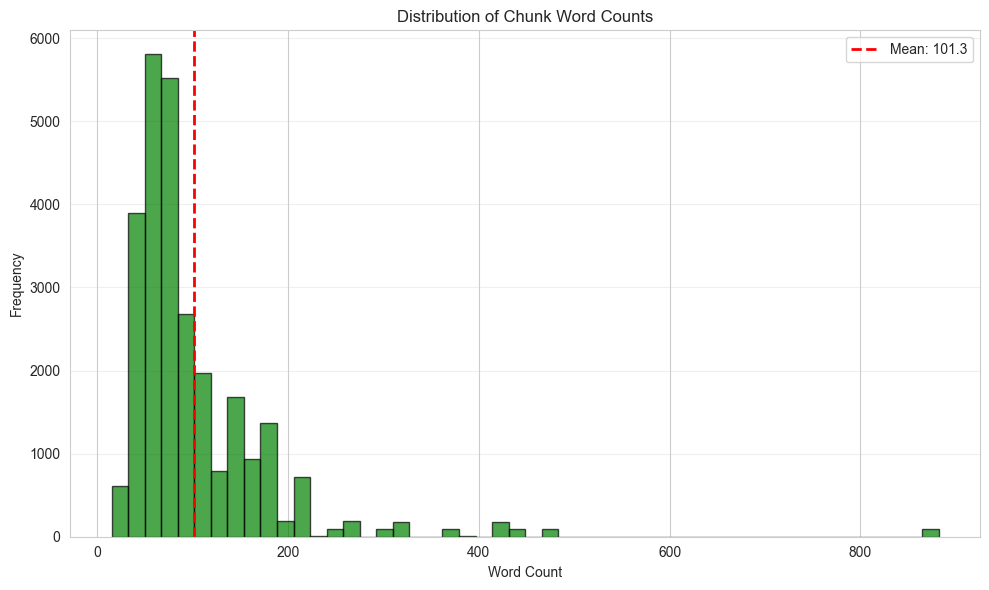

In [8]:
# Visualization 3: Word Count Distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['word_count'], bins=50, color='green', alpha=0.7, edgecolor='black')
mean_word_count = df['word_count'].mean()
ax.axvline(mean_word_count, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_word_count:.1f}')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Chunk Word Counts')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/visualizations/word_count_distribution.png', bbox_inches='tight', dpi=300)
print("✓ Saved: word_count_distribution.png")
plt.show()


✓ Saved: product_distribution.png


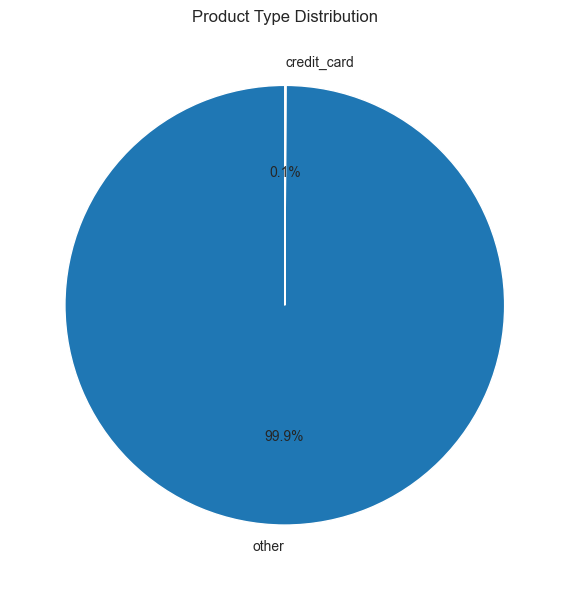

In [9]:
# Visualization 4: Product Type Distribution
fig, ax = plt.subplots(figsize=(10, 6))
product_counts = df['product_type'].value_counts()
ax.pie(product_counts.values, labels=product_counts.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Product Type Distribution')
plt.tight_layout()
plt.savefig('results/visualizations/product_distribution.png', bbox_inches='tight', dpi=300)
print("✓ Saved: product_distribution.png")
plt.show()


## 7. Export Data

Save the processed DataFrame to CSV for further analysis.


In [10]:
# Export DataFrame to CSV
try:
    df.to_csv('data/processed/chunks_metadata.csv', index=False)
    print("✓ DataFrame exported to: data/processed/chunks_metadata.csv")
except Exception as e:
    print(f"❌ Error exporting CSV: {e}")


✓ DataFrame exported to: data/processed/chunks_metadata.csv


## Summary

Data exploration complete! All visualizations have been saved to `results/visualizations/` and the processed data has been exported to `data/processed/chunks_metadata.csv`.


In [11]:
print("\n" + "=" * 50)
print("✓ Data exploration complete!")
print("✓ Visualizations saved to results/visualizations/")
print("✓ CSV file saved to data/processed/chunks_metadata.csv")
print("=" * 50)



✓ Data exploration complete!
✓ Visualizations saved to results/visualizations/
✓ CSV file saved to data/processed/chunks_metadata.csv
